In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset, DatasetDict, ClassLabel, Features, Value
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds["train"].to_pandas()

df = df[df["language"] == "en"].copy()

merge_classes = ["IT Support", "Technical Support", "Product Support"]
df["queue"] = df["queue"].replace(merge_classes, "Technical & IT Support")

df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")

In [3]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(
        r"\b(dear\s+customer\s+support\s+team|dear\s+support\s+team|hello\s+support|hi\s+team|greetings)[^\n,.]*[,:\-]?",
        "",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"i\s+hope\s+this\s+message\s+(finds|reaches)\s+you\s+well[.,]?",
        "",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["text"] = df["text"].apply(clean_text)

df["normalized_text"] = df["text"].str.lower().str.strip()
df = df.drop_duplicates(subset=["normalized_text"]).copy()

df["word_count"] = df["text"].apply(lambda x: len(x.split()))
df = df[df["word_count"] >= 8].copy()

In [4]:
from sklearn.utils import resample

print("Before balancing:")
print(df["queue"].value_counts())

tech_df = df[df["queue"] == "Technical & IT Support"]
other_df = df[df["queue"] != "Technical & IT Support"]

tech_downsampled = resample(
    tech_df,
    replace=False,
    n_samples=8000,   
    random_state=SEED
)

df = pd.concat([tech_downsampled, other_df])
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nAfter balancing:")
print(df["queue"].value_counts())

Before balancing:
queue
Technical & IT Support             14072
Customer Service                    3554
Billing and Payments                2405
Returns and Exchanges               1170
Service Outages and Maintenance      930
Sales and Pre-Sales                  720
Human Resources                      461
General Inquiry                      340
Name: count, dtype: int64

After balancing:
queue
Technical & IT Support             8000
Customer Service                   3554
Billing and Payments               2405
Returns and Exchanges              1170
Service Outages and Maintenance     930
Sales and Pre-Sales                 720
Human Resources                     461
General Inquiry                     340
Name: count, dtype: int64


In [5]:
queue_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

df["queue_id"] = queue_encoder.fit_transform(df["queue"])
df["priority_id"] = priority_encoder.fit_transform(df["priority"])

In [6]:
queue_class_label = ClassLabel(
    num_classes=len(queue_encoder.classes_),
    names=list(queue_encoder.classes_)
)

features = Features({
    "text": Value("string"),
    "queue_id": queue_class_label,
    "priority_id": Value("int64")
})

df = df.reset_index(drop=True)

hf_dataset = Dataset.from_pandas(
    df[["text", "queue_id", "priority_id"]],
    features=features
)

dataset = hf_dataset.train_test_split(
    test_size=0.3,
    seed=SEED,
    stratify_by_column="queue_id"
)

temp_split = dataset["test"].train_test_split(
    test_size=0.5,
    seed=SEED,
    stratify_by_column="queue_id"
)

dataset = DatasetDict({
    "train": dataset["train"],
    "validation": temp_split["train"],
    "test": temp_split["test"]
})

In [7]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

dataset = dataset.map(tokenize, batched=True)

c:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/12306 [00:00<?, ? examples/s]

Map:   0%|          | 0/2637 [00:00<?, ? examples/s]

Map:   0%|          | 0/2637 [00:00<?, ? examples/s]

In [8]:
def combine_labels(example):
    example["labels"] = [example["queue_id"], example["priority_id"]]
    return example

dataset = dataset.map(combine_labels)

dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

Map:   0%|          | 0/12306 [00:00<?, ? examples/s]

Map:   0%|          | 0/2637 [00:00<?, ? examples/s]

Map:   0%|          | 0/2637 [00:00<?, ? examples/s]

In [9]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    queue_logits, priority_logits = predictions

    queue_preds = np.argmax(queue_logits, axis=1)
    priority_preds = np.argmax(priority_logits, axis=1)

    queue_labels = labels[:, 0]
    priority_labels = labels[:, 1]

    return {
        "queue_accuracy": accuracy_score(queue_labels, queue_preds),
        "queue_macro_f1": f1_score(queue_labels, queue_preds, average="macro"),
        "priority_accuracy": accuracy_score(priority_labels, priority_preds),
        "priority_macro_f1": f1_score(priority_labels, priority_preds, average="macro"),
    }

In [10]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_queue_labels, num_priority_labels):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.queue_classifier = nn.Linear(hidden_size, num_queue_labels)
        self.priority_classifier = nn.Linear(hidden_size, num_priority_labels)

    def forward(self, input_ids, attention_mask, labels=None):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = outputs.last_hidden_state[:, 0]

        queue_logits = self.queue_classifier(pooled_output)
        priority_logits = self.priority_classifier(pooled_output)

        loss = None

        if labels is not None:
            queue_labels = labels[:, 0]
            priority_labels = labels[:, 1]

            loss_fct = nn.CrossEntropyLoss()

            queue_loss = loss_fct(queue_logits, queue_labels)
            priority_loss = loss_fct(priority_logits, priority_labels)

            loss = queue_loss + 0.5 * priority_loss

        return {
            "loss": loss,
            "logits": (queue_logits, priority_logits)
        }

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskModel(
    "distilbert-base-uncased",
    len(queue_encoder.classes_),
    len(priority_encoder.classes_)
).to(device)

training_args = TrainingArguments(
    output_dir="./v5_multitask_model_ds",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

  0%|          | 0/3080 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


{'loss': 1.8449, 'learning_rate': 1.6753246753246756e-05, 'epoch': 0.65}


  0%|          | 0/165 [00:00<?, ?it/s]

{'eval_loss': 1.695615291595459, 'eval_queue_accuracy': 0.5847554038680318, 'eval_queue_macro_f1': 0.3475235725154475, 'eval_priority_accuracy': 0.47023132347364427, 'eval_priority_macro_f1': 0.336299867079465, 'eval_runtime': 12.6378, 'eval_samples_per_second': 208.66, 'eval_steps_per_second': 13.056, 'epoch': 1.0}
{'loss': 1.6837, 'learning_rate': 1.3506493506493508e-05, 'epoch': 1.3}
{'loss': 1.5966, 'learning_rate': 1.025974025974026e-05, 'epoch': 1.95}


...

  0%|          | 0/165 [00:00<?, ?it/s]

{'eval_loss': 1.5988011360168457, 'eval_queue_accuracy': 0.6075085324232082, 'eval_queue_macro_f1': 0.4202947028835118, 'eval_priority_accuracy': 0.49829351535836175, 'eval_priority_macro_f1': 0.398291031882644, 'eval_runtime': 12.7824, 'eval_samples_per_second': 206.299, 'eval_steps_per_second': 12.908, 'epoch': 3.0}
{'loss': 1.3443, 'learning_rate': 3.7662337662337666e-06, 'epoch': 3.25}
{'loss': 1.2812, 'learning_rate': 5.194805194805196e-07, 'epoch': 3.9}


  0%|          | 0/165 [00:00<?, ?it/s]

{'eval_loss': 1.5663232803344727, 'eval_queue_accuracy': 0.6230565036025787, 'eval_queue_macro_f1': 0.44562030936059627, 'eval_priority_accuracy': 0.5047402351156617, 'eval_priority_macro_f1': 0.43591734622838924, 'eval_runtime': 12.5942, 'eval_samples_per_second': 209.381, 'eval_steps_per_second': 13.101, 'epoch': 4.0}
{'train_runtime': 769.4066, 'train_samples_per_second': 63.977, 'train_steps_per_second': 4.003, 'train_loss': 1.526251505566882, 'epoch': 4.0}


TrainOutput(global_step=3080, training_loss=1.526251505566882, metrics={'train_runtime': 769.4066, 'train_samples_per_second': 63.977, 'train_steps_per_second': 4.003, 'train_loss': 1.526251505566882, 'epoch': 4.0})

In [12]:
predictions = trainer.predict(dataset["test"])

metrics = predictions.metrics
print(metrics)

  0%|          | 0/165 [00:00<?, ?it/s]

{'test_loss': 1.6013413667678833, 'test_queue_accuracy': 0.6139552521805082, 'test_queue_macro_f1': 0.4419075685667173, 'test_priority_accuracy': 0.5180128934395146, 'test_priority_macro_f1': 0.44537734854158595, 'test_runtime': 12.599, 'test_samples_per_second': 209.303, 'test_steps_per_second': 13.096}


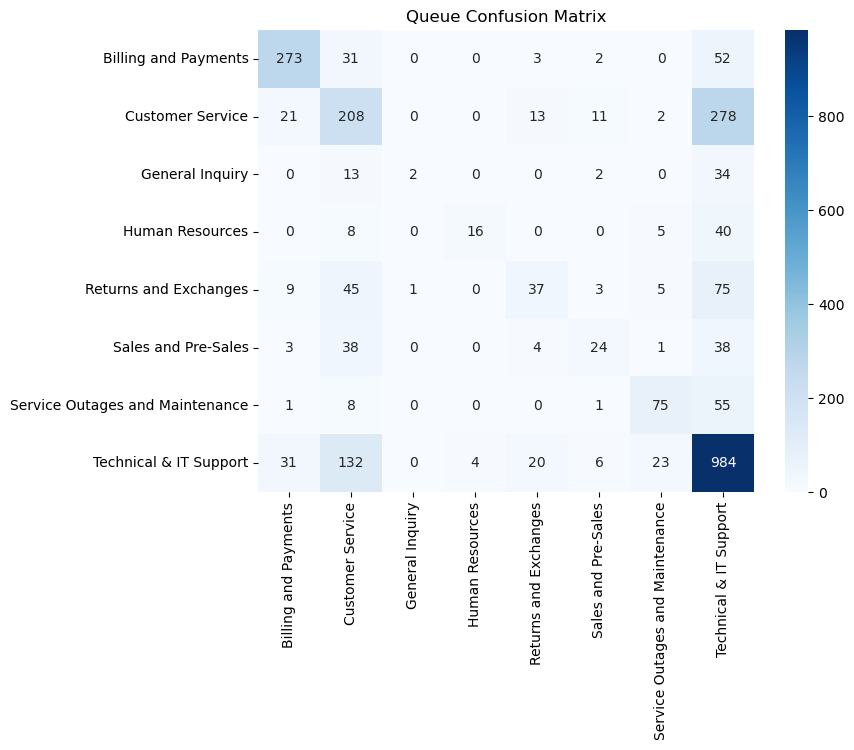

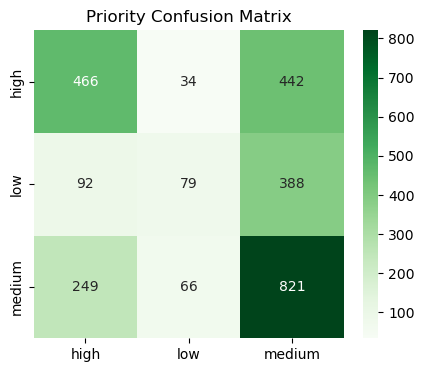

In [13]:
queue_logits, priority_logits = predictions.predictions
labels = predictions.label_ids

queue_preds = np.argmax(queue_logits, axis=1)
priority_preds = np.argmax(priority_logits, axis=1)

queue_labels = labels[:, 0]
priority_labels = labels[:, 1]

cm_queue = confusion_matrix(queue_labels, queue_preds)
cm_priority = confusion_matrix(priority_labels, priority_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_queue, annot=True, fmt="d",
            xticklabels=queue_encoder.classes_,
            yticklabels=queue_encoder.classes_,
            cmap="Blues")
plt.title("Queue Confusion Matrix")
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm_priority, annot=True, fmt="d",
            xticklabels=priority_encoder.classes_,
            yticklabels=priority_encoder.classes_,
            cmap="Greens")
plt.title("Priority Confusion Matrix")
plt.show()

In [14]:
print("QUEUE RESULTS")
print("Accuracy:", accuracy_score(queue_labels, queue_preds))
print("Macro F1:", f1_score(queue_labels, queue_preds, average="macro"))

print("\nPRIORITY RESULTS")
print("Accuracy:", accuracy_score(priority_labels, priority_preds))
print("Macro F1:", f1_score(priority_labels, priority_preds, average="macro"))

QUEUE RESULTS
Accuracy: 0.6139552521805082
Macro F1: 0.4419075685667173

PRIORITY RESULTS
Accuracy: 0.5180128934395146
Macro F1: 0.44537734854158595


In [15]:
os.makedirs("./saved_v5_multitask_ds", exist_ok=True)

torch.save(model.state_dict(), "./saved_v5_multitask_ds/model.pt")
tokenizer.save_pretrained("./saved_v5_multitask_ds")

import joblib
joblib.dump(queue_encoder, "./saved_v5_multitask_ds/queue_encoder.pkl")
joblib.dump(priority_encoder, "./saved_v5_multitask_ds/priority_encoder.pkl")

['./saved_v5_multitask_ds/priority_encoder.pkl']

In [16]:
model = MultiTaskModel(
    "distilbert-base-uncased",
    len(queue_encoder.classes_),
    len(priority_encoder.classes_)
)

model.load_state_dict(torch.load("./saved_v5_multitask_ds/model.pt"))
model.to(device)
model.eval()

c:\Users\nethr\anaconda3\envs\ticket-routing\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\nethr\AppData\Local\Temp\ipykernel_26096\539649157.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `to

MultiTaskModel(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linea

In [17]:
def predict(text):
    text = clean_text(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

        q_logits, p_logits = outputs["logits"]

        q_probs = torch.softmax(q_logits, dim=1)
        p_probs = torch.softmax(p_logits, dim=1)

        q_id = torch.argmax(q_probs, dim=1).item()
        p_id = torch.argmax(p_probs, dim=1).item()

    return {
        "queue": queue_encoder.inverse_transform([q_id])[0],
        "queue_confidence": q_probs.max().item(),
        "priority": priority_encoder.inverse_transform([p_id])[0],
        "priority_confidence": p_probs.max().item()
    }

In [18]:
test_1 = """
We are experiencing repeated crashes on our production server after the recent system update.
The database connection keeps failing and users are unable to access the dashboard.
This is affecting multiple departments and needs urgent attention.
"""

print(predict(test_1))

{'queue': 'Technical & IT Support', 'queue_confidence': 0.9699698686599731, 'priority': 'high', 'priority_confidence': 0.8757367730140686}


In [ ]:
test_2 = """
I was charged twice for my recent subscription renewal.
Could you please verify the invoice and process a refund for the duplicate payment?
"""

print(predict(test_2))

{'queue': 'Billing and Payments', 'queue_confidence': 0.9911530613899231, 'priority': 'medium', 'priority_confidence': 0.4074818193912506}


In [20]:
test_3 = """
I would like to know more about the features included in your premium plan.
Could you provide some additional documentation or a brochure?
"""

print(predict(test_3))

{'queue': 'Customer Service', 'queue_confidence': 0.33642712235450745, 'priority': 'low', 'priority_confidence': 0.457874059677124}


In [21]:
test_4 = """
I am having difficulty accessing the internal employee portal to submit my leave request.
The system does not recognize my credentials.
"""

print(predict(test_4))

{'queue': 'Human Resources', 'queue_confidence': 0.9632982015609741, 'priority': 'low', 'priority_confidence': 0.5194675922393799}


In [22]:
test_5 = """
I received the wrong product in my recent order.
Please advise how I can initiate a return and get the correct item shipped.
"""

print(predict(test_5))

{'queue': 'Returns and Exchanges', 'queue_confidence': 0.9372712969779968, 'priority': 'medium', 'priority_confidence': 0.4510924816131592}


In [23]:
SAVE_DIR = "./hf_multitask_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save encoder config & tokenizer
model.encoder.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save classification heads manually
torch.save({
    "queue_classifier": model.queue_classifier.state_dict(),
    "priority_classifier": model.priority_classifier.state_dict()
}, os.path.join(SAVE_DIR, "heads.pt"))

joblib.dump(queue_encoder, os.path.join(SAVE_DIR, "queue_encoder.pkl"))
joblib.dump(priority_encoder, os.path.join(SAVE_DIR, "priority_encoder.pkl"))

print("Saved HF-style multitask model.")

Saved HF-style multitask model.
